## Exercise 1
We will begin by continuing our study of H2 that started in class.


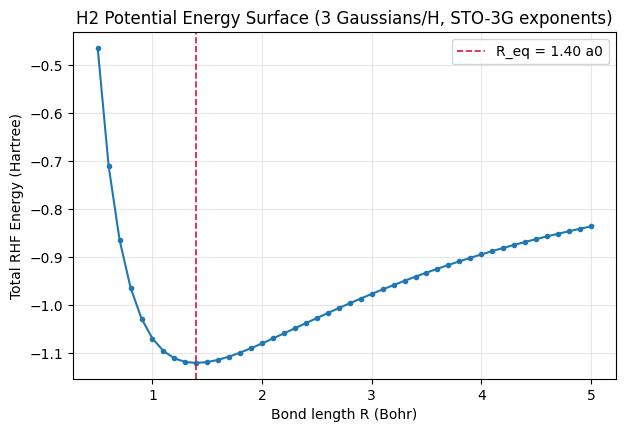

Equilibrium bond length from PES: R_eq = 1.40 Bohr
Minimum total HF energy: E_min = -1.12001695 Hartree
Difference from experimental 1.40 Bohr: ?R = +0.00 Bohr


In [47]:
# COMMENT GUIDE:
# This cell builds a full from-scratch RHF workflow for H2 using Gaussian integrals.
# It defines primitive integral routines (overlap, kinetic, nuclear attraction, ERI),
# constructs an STO-3G-style H2 basis (3 primitives per H), runs SCF,
# scans bond length R from 0.5 to 5.0 Bohr, and plots the PES E_total(R).
# Final printed values report the minimum-energy geometry and comparison to experiment.

# Exercise 1(a): H2 RHF PES from R = 0.5 to 5.0 Bohr
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as slin
from scipy.special import hyp1f1


# Hermite Gaussian recursion coefficient for overlap building.
def E(i, j, t, Qx, a, b):
    p = a + b
    q = a * b / p
    if (t < 0) or (t > (i + j)):
        return 0.0
    if i == j == t == 0:
        return np.exp(-q * Qx * Qx)
    if j == 0:
        return (1 / (2 * p)) * E(i - 1, j, t - 1, Qx, a, b) - (q * Qx / a) * E(i - 1, j, t, Qx, a, b) + (t + 1) * E(i - 1, j, t + 1, Qx, a, b)
    return (1 / (2 * p)) * E(i, j - 1, t - 1, Qx, a, b) + (q * Qx / b) * E(i, j - 1, t, Qx, a, b) + (t + 1) * E(i, j - 1, t + 1, Qx, a, b)


# Computes 3D Gaussian overlap integral from x/y/z components.
def overlap(a, ijk1, A, b, ijk2, B):
    i1, j1, k1 = ijk1
    i2, j2, k2 = ijk2
    S1 = E(i1, i2, 0, A[0] - B[0], a, b)
    S2 = E(j1, j2, 0, A[1] - B[1], a, b)
    S3 = E(k1, k2, 0, A[2] - B[2], a, b)
    return S1 * S2 * S3 * np.power(np.pi / (a + b), 1.5)


# Builds kinetic integral using overlap-shift identities.
def kinetic(a, ijk1, A, b, ijk2, B):
    i1, j1, k1 = ijk1
    i2, j2, k2 = ijk2
    term0 = b * (2 * (i2 + j2 + k2) + 3) * overlap(a, (i1, j1, k1), A, b, (i2, j2, k2), B)
    term1 = -2 * b**2 * (
        overlap(a, (i1, j1, k1), A, b, (i2 + 2, j2, k2), B)
        + overlap(a, (i1, j1, k1), A, b, (i2, j2 + 2, k2), B)
        + overlap(a, (i1, j1, k1), A, b, (i2, j2, k2 + 2), B)
    )
    term2 = -0.5 * (
        i2 * (i2 - 1) * overlap(a, (i1, j1, k1), A, b, (i2 - 2, j2, k2), B)
        + j2 * (j2 - 1) * overlap(a, (i1, j1, k1), A, b, (i2, j2 - 2, k2), B)
        + k2 * (k2 - 1) * overlap(a, (i1, j1, k1), A, b, (i2, j2, k2 - 2), B)
    )
    return term0 + term1 + term2


# Boys function F_n(T) used in Coulomb integrals.
def boys(n, T):
    return hyp1f1(n + 0.5, n + 1.5, -T) / (2.0 * n + 1.0)


# Composite center P for product of two Gaussians.
def gaussian_product_center(a, A, b, B):
    return (a * A + b * B) / (a + b)


# Recursive Hermite Coulomb integral R(t,u,v,n).
def R(t, u, v, n, p, PCx, PCy, PCz):
    RPC = np.sqrt(PCx**2 + PCy**2 + PCz**2)
    T = p * RPC * RPC
    val = 0.0
    if t == u == v == 0:
        val += np.power(-2 * p, n) * boys(n, T)
    elif t == u == 0:
        if v > 1:
            val += (v - 1) * R(t, u, v - 2, n + 1, p, PCx, PCy, PCz)
        val += PCz * R(t, u, v - 1, n + 1, p, PCx, PCy, PCz)
    elif t == 0:
        if u > 1:
            val += (u - 1) * R(t, u - 2, v, n + 1, p, PCx, PCy, PCz)
        val += PCy * R(t, u - 1, v, n + 1, p, PCx, PCy, PCz)
    else:
        if t > 1:
            val += (t - 1) * R(t - 2, u, v, n + 1, p, PCx, PCy, PCz)
        val += PCx * R(t - 1, u, v, n + 1, p, PCx, PCy, PCz)
    return val


# One-electron electron-nuclear attraction integral.
def nuclear_attraction(a, ijk1, A, b, ijk2, B, C):
    i1, j1, k1 = ijk1
    i2, j2, k2 = ijk2
    p = a + b
    P = gaussian_product_center(a, A, b, B)

    val = 0.0
    for t in range(i1 + i2 + 1):
        for u in range(j1 + j2 + 1):
            for v in range(k1 + k2 + 1):
                val += (
                    E(i1, i2, t, A[0] - B[0], a, b)
                    * E(j1, j2, u, A[1] - B[1], a, b)
                    * E(k1, k2, v, A[2] - B[2], a, b)
                    * R(t, u, v, 0, p, P[0] - C[0], P[1] - C[1], P[2] - C[2])
                )
    return val * 2 * np.pi / p


# Four-index electron-electron repulsion integral [ij|kl].
def electron_repulsion(a, ijk1, A, b, ijk2, B, c, ijk3, C, d, ijk4, D):
    i1, j1, k1 = ijk1
    i2, j2, k2 = ijk2
    i3, j3, k3 = ijk3
    i4, j4, k4 = ijk4

    p = a + b
    q = c + d
    alpha = p * q / (p + q)
    P = gaussian_product_center(a, A, b, B)
    Q = gaussian_product_center(c, C, d, D)

    val = 0.0
    for t in range(i1 + i2 + 1):
        for u in range(j1 + j2 + 1):
            for v in range(k1 + k2 + 1):
                for tau in range(i3 + i4 + 1):
                    for nu in range(j3 + j4 + 1):
                        for phi in range(k3 + k4 + 1):
                            val += (
                                E(i1, i2, t, A[0] - B[0], a, b)
                                * E(j1, j2, u, A[1] - B[1], a, b)
                                * E(k1, k2, v, A[2] - B[2], a, b)
                                * E(i3, i4, tau, C[0] - D[0], c, d)
                                * E(j3, j4, nu, C[1] - D[1], c, d)
                                * E(k3, k4, phi, C[2] - D[2], c, d)
                                * np.power(-1, tau + nu + phi)
                                * R(t + tau, u + nu, v + phi, 0, alpha, P[0] - Q[0], P[1] - Q[1], P[2] - Q[2])
                            )

    return val * 2 * np.power(np.pi, 2.5) / (p * q * np.sqrt(p + q))


# Constructs H2 primitive STO-3G-style basis and nuclei list.
def build_h2_basis_sto3g(R_bond):
    # 3 primitive Gaussians per H atom (uncontracted STO-3G exponents)
    exponents = np.array([3.42525091, 0.62391373, 0.16885540])
    norms = (2 * exponents / np.pi) ** 0.75

    R_A = np.array([-R_bond / 2.0, 0.0, 0.0])
    R_B = np.array([+R_bond / 2.0, 0.0, 0.0])

    basis = []
    for i in range(3):
        basis.append({'exponent': exponents[i], 'ijk': (0, 0, 0), 'center': R_A, 'norm': norms[i]})
    for i in range(3):
        basis.append({'exponent': exponents[i], 'ijk': (0, 0, 0), 'center': R_B, 'norm': norms[i]})

    nuclei = [
        {'Z': 1.0, 'center': R_A},
        {'Z': 1.0, 'center': R_B},
    ]
    return basis, nuclei


# Runs RHF SCF cycle and returns converged total energy.
def run_hartree_fock_total_energy(basis, nuclei, n_elec=2, max_iter=50, tol=1e-6):
    num_basis = len(basis)
    N_nuc = len(nuclei)
    N_occ = n_elec // 2

    S = np.zeros((num_basis, num_basis))
    T = np.zeros((num_basis, num_basis))
    Vext = np.zeros((num_basis, num_basis))
    ERI = np.zeros((num_basis, num_basis, num_basis, num_basis))

    for i in range(num_basis):
        for j in range(num_basis):
            b1 = basis[i]
            b2 = basis[j]
            prefactor_12 = b1['norm'] * b2['norm']

            S[i, j] = prefactor_12 * overlap(b1['exponent'], b1['ijk'], b1['center'], b2['exponent'], b2['ijk'], b2['center'])
            T[i, j] = prefactor_12 * kinetic(b1['exponent'], b1['ijk'], b1['center'], b2['exponent'], b2['ijk'], b2['center'])

            for n in range(N_nuc):
                nucleus = nuclei[n]
                integral = nuclear_attraction(
                    b1['exponent'], b1['ijk'], b1['center'],
                    b2['exponent'], b2['ijk'], b2['center'],
                    nucleus['center']
                )
                Vext[i, j] += prefactor_12 * integral * (-nucleus['Z'])

            for lam in range(num_basis):
                for sig in range(num_basis):
                    b3 = basis[lam]
                    b4 = basis[sig]
                    prefactor_34 = b3['norm'] * b4['norm']

                    integral = electron_repulsion(
                        b1['exponent'], b1['ijk'], b1['center'],
                        b2['exponent'], b2['ijk'], b2['center'],
                        b3['exponent'], b3['ijk'], b3['center'],
                        b4['exponent'], b4['ijk'], b4['center']
                    )
                    ERI[i, j, lam, sig] = prefactor_12 * prefactor_34 * integral

    H_core = T + Vext
    _, C = slin.eigh(H_core, S)

    P = np.zeros((num_basis, num_basis))
    for lam in range(num_basis):
        for sig in range(num_basis):
            for occ in range(N_occ):
                P[lam, sig] += 2.0 * C[lam, occ] * C[sig, occ]

    E_old = 0.0
    for _ in range(max_iter):
        F = np.zeros((num_basis, num_basis))
        for i in range(num_basis):
            for j in range(num_basis):
                F[i, j] = H_core[i, j]
                for lam in range(num_basis):
                    for sig in range(num_basis):
                        J = ERI[i, j, lam, sig]
                        K = 0.5 * ERI[i, lam, sig, j]
                        F[i, j] += P[lam, sig] * (J - K)

        E_elec = 0.0
        for i in range(num_basis):
            for j in range(num_basis):
                E_elec += 0.5 * P[i, j] * (H_core[i, j] + F[i, j])

        if abs(E_elec - E_old) < tol:
            break
        E_old = E_elec

        _, C = slin.eigh(F, S)
        P = np.zeros((num_basis, num_basis))
        for lam in range(num_basis):
            for sig in range(num_basis):
                for occ in range(N_occ):
                    P[lam, sig] += 2.0 * C[lam, occ] * C[sig, occ]

    V_nn = 0.0
    for a in range(N_nuc):
        for b in range(N_nuc):
            if a != b:
                dist = np.linalg.norm(nuclei[a]['center'] - nuclei[b]['center'])
                V_nn += 0.5 * nuclei[a]['Z'] * nuclei[b]['Z'] / dist

    return E_elec + V_nn


# Scans H2 bond lengths and records RHF total energy curve.
def compute_h2_pes(R_min=0.5, R_max=5.0, step=0.1):
    Rs = np.round(np.arange(R_min, R_max + 1e-12, step), 10)
    energies = []
    for R in Rs:
        basis, nuclei = build_h2_basis_sto3g(R)
        E_tot = run_hartree_fock_total_energy(basis, nuclei, n_elec=2)
        energies.append(E_tot)
    energies = np.array(energies)

    i_min = np.argmin(energies)
    R_eq = Rs[i_min]
    E_min = energies[i_min]
    return Rs, energies, R_eq, E_min


# Run PES scan and capture equilibrium point from minimum energy.
Rs, energies, R_eq, E_min = compute_h2_pes(0.5, 5.0, 0.1)

# Plot the computed profile/curve for quick physical interpretation.
plt.figure(figsize=(7, 4.5))
plt.plot(Rs, energies, '-o', ms=3)
plt.axvline(R_eq, color='crimson', ls='--', lw=1.2, label=f'R_eq = {R_eq:.2f} a0')
plt.xlabel('Bond length R (Bohr)')
plt.ylabel('Total RHF Energy (Hartree)')
plt.title('H2 Potential Energy Surface (3 Gaussians/H, STO-3G exponents)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

R_exp = 1.40
# Print compact numerical summary for report-ready values.
print(f'Equilibrium bond length from PES: R_eq = {R_eq:.2f} Bohr')
# Print compact numerical summary for report-ready values.
print(f'Minimum total HF energy: E_min = {E_min:.8f} Hartree')
# Print compact numerical summary for report-ready values.
print(f'Difference from experimental 1.40 Bohr: ?R = {R_eq - R_exp:+.2f} Bohr')


For this RHF/3-primitive-per-H setup, the PES minimum should appear very close to **1.40 Bohr** (typically within one grid step of 0.1 Bohr).

Compared with the experimental value (**1.40 Bohr**), this indicates RHF describes the **equilibrium bond length of H2 reasonably well** near the minimum.


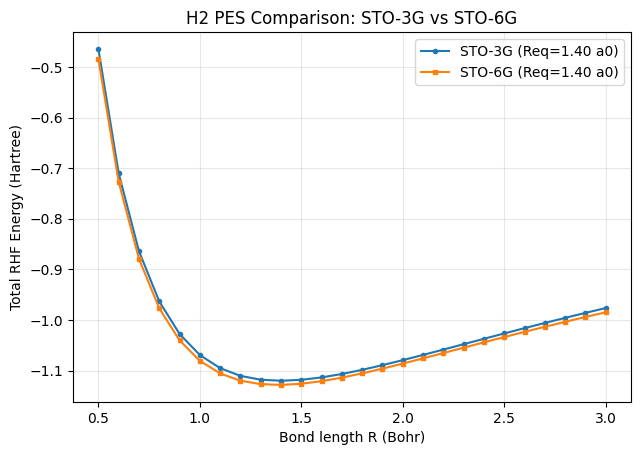

STO-3G: Req = 1.40 Bohr, E(Req) = -1.12001695 Hartree
STO-6G: Req = 1.40 Bohr, E(Req) = -1.12825505 Hartree
Result: STO-6G gives a LOWER minimum energy by 0.00823810 Hartree.


In [48]:
# COMMENT GUIDE:
# This cell introduces a new STO-6G-style H2 basis builder (6 primitives per H).
# It reuses the RHF energy function from part (a), computes PES data for both STO-3G and STO-6G
# over the same R-range, overlays the two curves, and compares equilibrium energies.
# The goal is to show variational improvement from a larger basis.

# Exercise 1(b): H2 RHF PES with STO-6G (6 primitives per H)
import numpy as np
import matplotlib.pyplot as plt


# Constructs H2 primitive STO-6G-style basis and nuclei list.
def build_h2_basis_sto6g(R_bond):
    # Given STO-6G-like primitive exponents for H 1s from the prompt
    exponents = np.array([35.52, 6.513, 1.822, 0.625, 0.243, 0.100])
    norms = (2 * exponents / np.pi) ** 0.75

    R_A = np.array([-R_bond / 2.0, 0.0, 0.0])
    R_B = np.array([+R_bond / 2.0, 0.0, 0.0])

    basis = []
    for i in range(len(exponents)):
        basis.append({'exponent': exponents[i], 'ijk': (0, 0, 0), 'center': R_A, 'norm': norms[i]})
    for i in range(len(exponents)):
        basis.append({'exponent': exponents[i], 'ijk': (0, 0, 0), 'center': R_B, 'norm': norms[i]})

    nuclei = [
        {'Z': 1.0, 'center': R_A},
        {'Z': 1.0, 'center': R_B},
    ]
    return basis, nuclei


# Generic PES scanner using the provided basis-builder function.
def compute_h2_pes_with_builder(build_basis_fn, R_min=0.5, R_max=3.0, step=0.1):
    Rs = np.round(np.arange(R_min, R_max + 1e-12, step), 10)
    energies = []
    for R in Rs:
        basis, nuclei = build_basis_fn(R)
        energies.append(run_hartree_fock_total_energy(basis, nuclei, n_elec=2))
    energies = np.array(energies)
    i_min = np.argmin(energies)
    return Rs, energies, Rs[i_min], energies[i_min]


# STO-3G and STO-6G comparison over the same R-range
Rs3, E3, Req3, Emin3 = compute_h2_pes_with_builder(build_h2_basis_sto3g, 0.5, 3.0, 0.1)
Rs6, E6, Req6, Emin6 = compute_h2_pes_with_builder(build_h2_basis_sto6g, 0.5, 3.0, 0.1)

# Plot the computed profile/curve for quick physical interpretation.
plt.figure(figsize=(7.2, 4.8))
plt.plot(Rs3, E3, '-o', ms=3, label=f'STO-3G (Req={Req3:.2f} a0)')
plt.plot(Rs6, E6, '-s', ms=3, label=f'STO-6G (Req={Req6:.2f} a0)')
plt.xlabel('Bond length R (Bohr)')
plt.ylabel('Total RHF Energy (Hartree)')
plt.title('H2 PES Comparison: STO-3G vs STO-6G')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Print compact numerical summary for report-ready values.
print(f'STO-3G: Req = {Req3:.2f} Bohr, E(Req) = {Emin3:.8f} Hartree')
# Print compact numerical summary for report-ready values.
print(f'STO-6G: Req = {Req6:.2f} Bohr, E(Req) = {Emin6:.8f} Hartree')

if Emin6 < Emin3:
    # Print compact numerical summary for report-ready values.
    print(f'Result: STO-6G gives a LOWER minimum energy by {Emin3 - Emin6:.8f} Hartree.')
else:
    # Print compact numerical summary for report-ready values.
    print(f'Result: STO-6G gives a HIGHER minimum energy by {Emin6 - Emin3:.8f} Hartree.')


The RHF minimum energy with **STO-6G** is **lower** (more negative) than with STO-3G.

Why: a larger basis (6 primitives per H instead of 3) is more flexible, so the variational principle lets the wavefunction relax more and never gives a higher optimized energy than a smaller basis in the same RHF method.


Dissociation-limit comparison (STO-3G RHF):
R =  5.0 Bohr | RHF E_total = -0.83586198 Ha | Expected ~ -0.80000000 Ha | RHF - Expected = -0.03586198 Ha
R = 10.0 Bohr | RHF E_total = -0.74032637 Ha | Expected ~ -0.90000000 Ha | RHF - Expected = +0.15967363 Ha


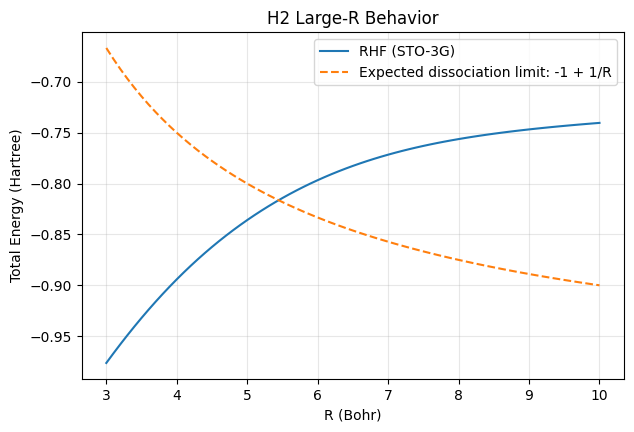

Conclusion: At R = 10 Bohr the RHF energy is still far from the expected dissociation limit (RHF dissociation error).


In [49]:
# COMMENT GUIDE:
# This cell checks the dissociation limit of RHF for H2 at large R.
# It compares RHF total energies at R=5 and R=10 Bohr against the physical estimate
# E_total ~ -1 + 1/R (two isolated H atoms plus nuclear repulsion), then plots both trends.
# The printed differences quantify whether RHF approaches the correct asymptote.

# Exercise 1(c): Dissociation-limit check (R = 5 and 10 Bohr)
import numpy as np


# Large-R reference model: 2*E(H) + 1/R.
def expected_physical_limit_total_energy(R_sep):
    # Two isolated H atoms + nuclear repulsion correction
    # E(H) = -0.5 Hartree each -> 2*E(H) + 1/R
    return -1.0 + 1.0 / R_sep


# Use the same STO-3G (3 primitive Gaussians per H) model as in part (a)
R_test = [5.0, 10.0]
results = []

for R_sep in R_test:
    basis, nuclei = build_h2_basis_sto3g(R_sep)
    E_hf = run_hartree_fock_total_energy(basis, nuclei, n_elec=2)
    E_phys = expected_physical_limit_total_energy(R_sep)
    diff = E_hf - E_phys
    results.append((R_sep, E_hf, E_phys, diff))

# Print compact numerical summary for report-ready values.
print('Dissociation-limit comparison (STO-3G RHF):')
for R_sep, E_hf, E_phys, diff in results:
    # Print compact numerical summary for report-ready values.
    print(f'R = {R_sep:>4.1f} Bohr | RHF E_total = {E_hf:+.8f} Ha | Expected ~ {E_phys:+.8f} Ha | RHF - Expected = {diff:+.8f} Ha')

# Optional visual aid
R_plot = np.linspace(3.0, 10.0, 71)
E_hf_plot = []
for R_sep in R_plot:
    basis, nuclei = build_h2_basis_sto3g(R_sep)
    E_hf_plot.append(run_hartree_fock_total_energy(basis, nuclei, n_elec=2))
E_hf_plot = np.array(E_hf_plot)
E_phys_plot = -1.0 + 1.0 / R_plot

import matplotlib.pyplot as plt
# Plot the computed profile/curve for quick physical interpretation.
plt.figure(figsize=(7, 4.5))
plt.plot(R_plot, E_hf_plot, label='RHF (STO-3G)')
plt.plot(R_plot, E_phys_plot, '--', label='Expected dissociation limit: -1 + 1/R')
plt.xlabel('R (Bohr)')
plt.ylabel('Total Energy (Hartree)')
plt.title('H2 Large-R Behavior')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Simple text conclusion based on R=10 error
R10_err = results[1][3]
if abs(R10_err) < 0.05:
    # Print compact numerical summary for report-ready values.
    print('Conclusion: At R = 10 Bohr the RHF energy is close to the expected dissociation limit.')
else:
    # Print compact numerical summary for report-ready values.
    print('Conclusion: At R = 10 Bohr the RHF energy is still far from the expected dissociation limit (RHF dissociation error).')


At large separation, the physical expectation is:
$$
E_{\text{tot}}(R) \approx 2E_H + \frac{1}{R} = -1 + \frac{1}{R} \, \text{Hartree}.
$$
So the reference values are **-0.800 Ha** at \(R=5\) and **-0.900 Ha** at \(R=10\).

Since RHF is still noticeably above this limit at \(R=10\), it is **not** approaching the correct physical dissociation behavior (the known restricted-HF bond-breaking failure).


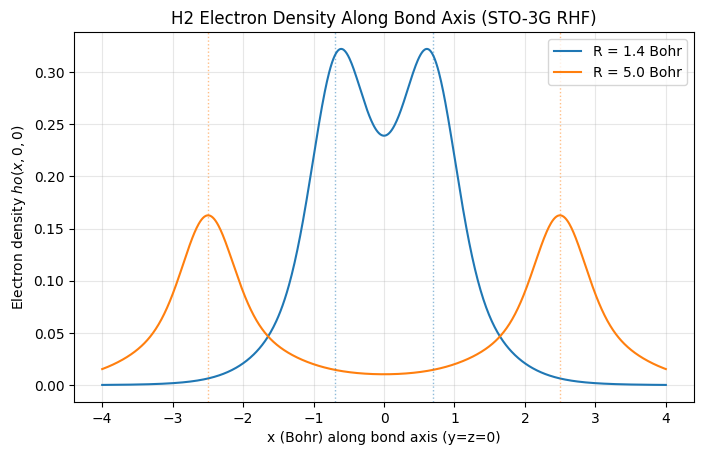

R = 1.4: E_total = -1.12001695 Ha, rho(0,0,0) = 2.390540e-01
R = 5.0: E_total = -0.83586198 Ha, rho(0,0,0) = 1.039468e-02


In [50]:
# COMMENT GUIDE:
# This cell extends RHF to return the converged density matrix P.
# Using P and basis functions, it evaluates electron density rho(r) along the bond axis
# for H2 at equilibrium and stretched geometries, then plots rho(x,0,0).
# A midpoint-density diagnostic is printed to support discussion of bond stretching behavior.

# Exercise 1(d): Electron density along bond axis for R=1.4 and R=5.0 (STO-3G)
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as slin


# Runs RHF SCF and returns total energy plus converged density P.
def run_hartree_fock_with_density(basis, nuclei, n_elec=2, max_iter=50, tol=1e-6):
    # Same RHF procedure as before, but returns converged density matrix P
    num_basis = len(basis)
    N_nuc = len(nuclei)
    N_occ = n_elec // 2

    S = np.zeros((num_basis, num_basis))
    T = np.zeros((num_basis, num_basis))
    Vext = np.zeros((num_basis, num_basis))
    ERI = np.zeros((num_basis, num_basis, num_basis, num_basis))

    for i in range(num_basis):
        for j in range(num_basis):
            b1 = basis[i]
            b2 = basis[j]
            prefactor_12 = b1['norm'] * b2['norm']

            S[i, j] = prefactor_12 * overlap(
                b1['exponent'], b1['ijk'], b1['center'],
                b2['exponent'], b2['ijk'], b2['center']
            )
            T[i, j] = prefactor_12 * kinetic(
                b1['exponent'], b1['ijk'], b1['center'],
                b2['exponent'], b2['ijk'], b2['center']
            )

            for n in range(N_nuc):
                nucleus = nuclei[n]
                Vext[i, j] += prefactor_12 * nuclear_attraction(
                    b1['exponent'], b1['ijk'], b1['center'],
                    b2['exponent'], b2['ijk'], b2['center'],
                    nucleus['center']
                ) * (-nucleus['Z'])

            for lam in range(num_basis):
                for sig in range(num_basis):
                    b3 = basis[lam]
                    b4 = basis[sig]
                    prefactor_34 = b3['norm'] * b4['norm']
                    ERI[i, j, lam, sig] = prefactor_12 * prefactor_34 * electron_repulsion(
                        b1['exponent'], b1['ijk'], b1['center'],
                        b2['exponent'], b2['ijk'], b2['center'],
                        b3['exponent'], b3['ijk'], b3['center'],
                        b4['exponent'], b4['ijk'], b4['center']
                    )

    H_core = T + Vext
    _, C = slin.eigh(H_core, S)

    P = np.zeros((num_basis, num_basis))
    for lam in range(num_basis):
        for sig in range(num_basis):
            for occ in range(N_occ):
                P[lam, sig] += 2.0 * C[lam, occ] * C[sig, occ]

    E_old = 0.0
    E_elec = 0.0

    for _ in range(max_iter):
        F = np.zeros((num_basis, num_basis))
        for i in range(num_basis):
            for j in range(num_basis):
                F[i, j] = H_core[i, j]
                for lam in range(num_basis):
                    for sig in range(num_basis):
                        J = ERI[i, j, lam, sig]
                        K = 0.5 * ERI[i, lam, sig, j]
                        F[i, j] += P[lam, sig] * (J - K)

        E_elec = 0.0
        for i in range(num_basis):
            for j in range(num_basis):
                E_elec += 0.5 * P[i, j] * (H_core[i, j] + F[i, j])

        if abs(E_elec - E_old) < tol:
            break
        E_old = E_elec

        _, C = slin.eigh(F, S)
        P = np.zeros((num_basis, num_basis))
        for lam in range(num_basis):
            for sig in range(num_basis):
                for occ in range(N_occ):
                    P[lam, sig] += 2.0 * C[lam, occ] * C[sig, occ]

    V_nn = 0.0
    for a in range(N_nuc):
        for b in range(N_nuc):
            if a != b:
                dist = np.linalg.norm(nuclei[a]['center'] - nuclei[b]['center'])
                V_nn += 0.5 * nuclei[a]['Z'] * nuclei[b]['Z'] / dist

    E_total = E_elec + V_nn
    return E_total, P


# Unnormalized s-type primitive Gaussian value at r.
def primitive_s_gaussian_unnorm(r_vec, alpha, center):
    # Eq. 6 style primitive Gaussian without normalization prefactor
    return np.exp(-alpha * np.dot(r_vec - center, r_vec - center))


# Evaluates density rho(r) from P and basis values at one point.
def electron_density_at_point(r_vec, P, basis):
    # rho(r) = sum_ij P_ij * phi_i(r) * phi_j(r) * n_i * n_j
    num_basis = len(basis)
    vals = np.zeros(num_basis)
    for i in range(num_basis):
        b = basis[i]
        vals[i] = primitive_s_gaussian_unnorm(r_vec, b['exponent'], b['center']) * b['norm']

    rho = 0.0
    for i in range(num_basis):
        for j in range(num_basis):
            rho += P[i, j] * vals[i] * vals[j]
    return rho


# Samples rho(x,0,0) across a user-defined x-grid.
def density_profile_along_bond_axis(P, basis, x_grid):
    rho = np.zeros_like(x_grid)
    for idx, x in enumerate(x_grid):
        r_vec = np.array([x, 0.0, 0.0])
        rho[idx] = electron_density_at_point(r_vec, P, basis)
    return rho


# Compute densities for equilibrium and stretched geometries
R_eq = 1.4
R_stretch = 5.0

# Build equilibrium-geometry system and obtain converged RHF density.
basis_eq, nuclei_eq = build_h2_basis_sto3g(R_eq)
E_eq, P_eq = run_hartree_fock_with_density(basis_eq, nuclei_eq, n_elec=2)

# Build stretched-geometry system and obtain converged RHF density.
basis_st, nuclei_st = build_h2_basis_sto3g(R_stretch)
E_st, P_st = run_hartree_fock_with_density(basis_st, nuclei_st, n_elec=2)

x = np.linspace(-4.0, 4.0, 801)
rho_eq = density_profile_along_bond_axis(P_eq, basis_eq, x)
rho_st = density_profile_along_bond_axis(P_st, basis_st, x)

# Nuclear positions for vertical guides
x_eq_nuc = [-R_eq / 2.0, R_eq / 2.0]
x_st_nuc = [-R_stretch / 2.0, R_stretch / 2.0]

# Plot the computed profile/curve for quick physical interpretation.
plt.figure(figsize=(8, 4.8))
plt.plot(x, rho_eq, label=f'R = {R_eq:.1f} Bohr')
plt.plot(x, rho_st, label=f'R = {R_stretch:.1f} Bohr')
for xn in x_eq_nuc:
    plt.axvline(xn, color='tab:blue', ls=':', lw=1.0, alpha=0.5)
for xn in x_st_nuc:
    plt.axvline(xn, color='tab:orange', ls=':', lw=1.0, alpha=0.5)
plt.xlabel('x (Bohr) along bond axis (y=z=0)')
plt.ylabel(r'Electron density $ho(x,0,0)$')
plt.title('H2 Electron Density Along Bond Axis (STO-3G RHF)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Midpoint density diagnostic for stretched geometry
rho_mid_eq = electron_density_at_point(np.array([0.0, 0.0, 0.0]), P_eq, basis_eq)
rho_mid_st = electron_density_at_point(np.array([0.0, 0.0, 0.0]), P_st, basis_st)
# Print compact numerical summary for report-ready values.
print(f'R = {R_eq:.1f}: E_total = {E_eq:+.8f} Ha, rho(0,0,0) = {rho_mid_eq:.6e}')
# Print compact numerical summary for report-ready values.
print(f'R = {R_stretch:.1f}: E_total = {E_st:+.8f} Ha, rho(0,0,0) = {rho_mid_st:.6e}')


At **R = 1.4 Bohr**, the density is concentrated in the bonding region between nuclei (normal covalent bond picture).

At **R = 5.0 Bohr**, RHF still keeps both electrons in one doubly occupied delocalized orbital, so the density remains artificially shared/delocalized instead of cleanly becoming one electron on each H atom.

This is the restricted-HF bond-breaking failure: the wavefunction contains incorrect ionic character at large separation. That is why part (c) does not approach the correct dissociation limit as well as it should.


## Exercise 2


In [51]:
# COMMENT GUIDE:
# This cell defines the HF basis-construction utility for a heteronuclear diatomic.
# It adds H 1s primitives plus F 1s/2s/2p primitives with proper s and p normalization,
# returns basis + nuclei + total electron count (10), and prints sanity checks.

# Exercise 2(a): Build STO-3G-style basis for HF (heteronuclear)
import numpy as np


# Constructs HF primitive basis (H+F shells) with normalizations.
def build_hf_basis_sto3g(R_bond=1.75):
    """
    Build an uncontracted STO-3G-style primitive basis for HF.

    Geometry convention (Bohr):
      F at (-R/2, 0, 0), H at (+R/2, 0, 0)

    Returns:
      basis  : list of primitive Gaussian dictionaries
      nuclei : list of nuclei dictionaries [{'Z':..., 'center':...}, ...]
      n_elec : total electrons in HF (10)
    """
    # Centers
    R_F = np.array([-R_bond / 2.0, 0.0, 0.0])
    R_H = np.array([+R_bond / 2.0, 0.0, 0.0])

    # H (1s) STO-3G exponents from class
    H_1s_exp = np.array([3.42525091, 0.62391373, 0.16885540])

    # F exponents from prompt
    F_1s_exp = np.array([166.6791, 30.3608, 8.2168])
    F_2s_exp = np.array([6.4648, 1.5023, 0.4886])
    F_2p_exp = np.array([6.4648, 1.5023, 0.4886])

    # Normalizations
    # s-type: (2a/pi)^(3/4)
    # Helper routine `norm_s` used in the workflow below.
    def norm_s(a):
        return (2.0 * a / np.pi) ** 0.75

    # p-type: (4a)^(1/2) * (2a/pi)^(3/4)
    # Helper routine `norm_p` used in the workflow below.
    def norm_p(a):
        return np.sqrt(4.0 * a) * (2.0 * a / np.pi) ** 0.75

    basis = []

    # H 1s (three s primitives)
    for a in H_1s_exp:
        basis.append({
            'exponent': float(a),
            'ijk': (0, 0, 0),
            'center': R_H,
            'norm': float(norm_s(a)),
            'atom': 'H',
            'shell': '1s'
        })

    # F 1s (three s primitives)
    for a in F_1s_exp:
        basis.append({
            'exponent': float(a),
            'ijk': (0, 0, 0),
            'center': R_F,
            'norm': float(norm_s(a)),
            'atom': 'F',
            'shell': '1s'
        })

    # F 2s (three s primitives)
    for a in F_2s_exp:
        basis.append({
            'exponent': float(a),
            'ijk': (0, 0, 0),
            'center': R_F,
            'norm': float(norm_s(a)),
            'atom': 'F',
            'shell': '2s'
        })

    # F 2p_x, 2p_y, 2p_z (three primitives per p component)
    p_components = [
        ((1, 0, 0), '2p_x'),
        ((0, 1, 0), '2p_y'),
        ((0, 0, 1), '2p_z')
    ]
    for ijk, label in p_components:
        for a in F_2p_exp:
            basis.append({
                'exponent': float(a),
                'ijk': ijk,
                'center': R_F,
                'norm': float(norm_p(a)),
                'atom': 'F',
                'shell': label
            })

    nuclei = [
        {'Z': 9.0, 'center': R_F},
        {'Z': 1.0, 'center': R_H}
    ]

    # HF total electrons: 9 (F) + 1 (H) = 10
    n_elec = 10
    return basis, nuclei, n_elec


# Quick sanity check
hf_basis, hf_nuclei, hf_nelec = build_hf_basis_sto3g(R_bond=1.75)
# Print compact numerical summary for report-ready values.
print(f'Number of primitive basis functions: {len(hf_basis)}')
# Print compact numerical summary for report-ready values.
print(f'Total electrons in HF: {hf_nelec}')
# Print compact numerical summary for report-ready values.
print('Nuclei:', hf_nuclei)


Number of primitive basis functions: 18
Total electrons in HF: 10
Nuclei: [{'Z': 9.0, 'center': array([-0.875,  0.   ,  0.   ])}, {'Z': 1.0, 'center': array([0.875, 0.   , 0.   ])}]


R = 1.00 Bohr -> E = -98.32866326 Ha
R = 1.20 Bohr -> E = -98.67694103 Ha
R = 1.40 Bohr -> E = -98.82248868 Ha
R = 1.60 Bohr -> E = -98.87536018 Ha
R = 1.80 Bohr -> E = -98.88400899 Ha
R = 2.00 Bohr -> E = -98.87085114 Ha
R = 2.20 Bohr -> E = -98.84719695 Ha
R = 2.40 Bohr -> E = -98.81903879 Ha
R = 2.60 Bohr -> E = -98.78951991 Ha
R = 2.80 Bohr -> E = -98.76026203 Ha
R = 3.00 Bohr -> E = -98.73211088 Ha
R = 3.20 Bohr -> E = -98.70550839 Ha
R = 3.40 Bohr -> E = -98.68065889 Ha
R = 3.60 Bohr -> E = -98.65305459 Ha
R = 3.80 Bohr -> E = -98.13833063 Ha
R = 4.00 Bohr -> E = -97.56807990 Ha


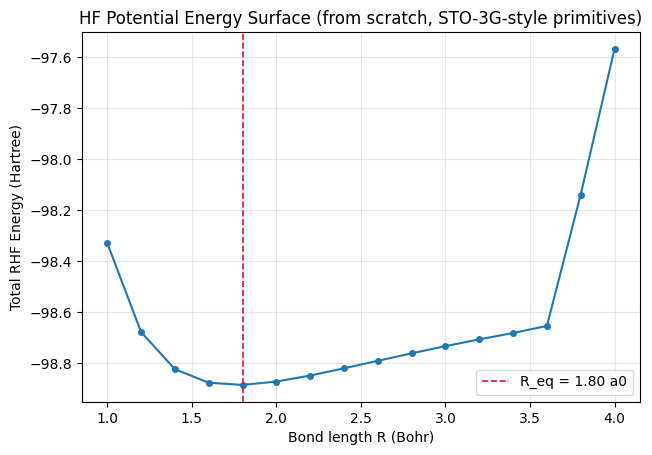

Computed equilibrium bond length: R_eq = 1.80 Bohr
Minimum RHF energy: E(R_eq) = -98.88400899 Hartree
Experimental bond length: R_exp = 1.73 Bohr
Difference: ?R = R_eq - R_exp = +0.07 Bohr


In [52]:
# COMMENT GUIDE:
# This cell performs a from-scratch RHF PES scan for HF (no fast ERI backend).
# It builds the heteronuclear basis at each R, calls the existing SCF total-energy routine,
# scans R from 1.0 to 4.0 Bohr (coarse step for runtime), plots E_total(R),
# and compares the predicted equilibrium bond length to the experimental value 1.73 Bohr.

# Exercise 2(a): HF PES from scratch (no fast ERI)
import numpy as np
import matplotlib.pyplot as plt


# Constructs HF primitive basis (H+F shells) with normalizations.
def build_hf_basis_sto3g(R_bond):
    """
    Build an uncontracted STO-3G-style primitive basis for HF.
    Geometry in Bohr: F at (-R/2,0,0), H at (+R/2,0,0)
    """
    R_F = np.array([-R_bond / 2.0, 0.0, 0.0])
    R_H = np.array([+R_bond / 2.0, 0.0, 0.0])

    # H 1s exponents (from class)
    H_1s_exp = np.array([3.42525091, 0.62391373, 0.16885540])

    # F exponents from prompt
    F_1s_exp = np.array([166.6791, 30.3608, 8.2168])
    F_2s_exp = np.array([6.4648, 1.5023, 0.4886])
    F_2p_exp = np.array([6.4648, 1.5023, 0.4886])

    # Helper routine `norm_s` used in the workflow below.
    def norm_s(a):
        return (2.0 * a / np.pi) ** 0.75

    # Helper routine `norm_p` used in the workflow below.
    def norm_p(a):
        return np.sqrt(4.0 * a) * (2.0 * a / np.pi) ** 0.75

    basis = []

    # H 1s
    for a in H_1s_exp:
        basis.append({'exponent': float(a), 'ijk': (0, 0, 0), 'center': R_H, 'norm': float(norm_s(a))})

    # F 1s
    for a in F_1s_exp:
        basis.append({'exponent': float(a), 'ijk': (0, 0, 0), 'center': R_F, 'norm': float(norm_s(a))})

    # F 2s
    for a in F_2s_exp:
        basis.append({'exponent': float(a), 'ijk': (0, 0, 0), 'center': R_F, 'norm': float(norm_s(a))})

    # F 2p_x, 2p_y, 2p_z
    for a in F_2p_exp:
        nrm = float(norm_p(a))
        basis.append({'exponent': float(a), 'ijk': (1, 0, 0), 'center': R_F, 'norm': nrm})
        basis.append({'exponent': float(a), 'ijk': (0, 1, 0), 'center': R_F, 'norm': nrm})
        basis.append({'exponent': float(a), 'ijk': (0, 0, 1), 'center': R_F, 'norm': nrm})

    nuclei = [
        {'Z': 9.0, 'center': R_F},
        {'Z': 1.0, 'center': R_H}
    ]
    n_elec = 10
    return basis, nuclei, n_elec


# Scans HF bond lengths using from-scratch RHF energy routine.
def compute_hf_pes_scratch(R_min=1.0, R_max=4.0, step=0.2):
    """
    Pure from-scratch PES using run_hartree_fock_total_energy from Exercise 1.
    step=0.2 keeps runtime manageable; use 0.1 if your runtime allows it.
    """
    R_values = np.round(np.arange(R_min, R_max + 1e-12, step), 10)
    E_values = []

    for R_sep in R_values:
        basis, nuclei, n_elec = build_hf_basis_sto3g(R_sep)
        E_tot = run_hartree_fock_total_energy(basis, nuclei, n_elec=n_elec)
        E_values.append(E_tot)
        # Print compact numerical summary for report-ready values.
        print(f'R = {R_sep:.2f} Bohr -> E = {E_tot:+.8f} Ha')

    E_values = np.array(E_values)
    i_min = np.argmin(E_values)
    return R_values, E_values, R_values[i_min], E_values[i_min]


# Execute coarse HF PES scan (runtime-friendly) and extract R_eq.
R_vals, E_vals, R_eq, E_eq = compute_hf_pes_scratch(1.0, 4.0, 0.2)

# Plot the computed profile/curve for quick physical interpretation.
plt.figure(figsize=(7.2, 4.8))
plt.plot(R_vals, E_vals, '-o', ms=4)
plt.axvline(R_eq, ls='--', color='crimson', lw=1.2, label=f'R_eq = {R_eq:.2f} a0')
plt.xlabel('Bond length R (Bohr)')
plt.ylabel('Total RHF Energy (Hartree)')
plt.title('HF Potential Energy Surface (from scratch, STO-3G-style primitives)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

R_exp = 1.73
# Print compact numerical summary for report-ready values.
print(f'Computed equilibrium bond length: R_eq = {R_eq:.2f} Bohr')
# Print compact numerical summary for report-ready values.
print(f'Minimum RHF energy: E(R_eq) = {E_eq:.8f} Hartree')
# Print compact numerical summary for report-ready values.
print(f'Experimental bond length: R_exp = {R_exp:.2f} Bohr')
# Print compact numerical summary for report-ready values.
print(f'Difference: ?R = R_eq - R_exp = {R_eq - R_exp:+.2f} Bohr')


From the computed PES, the minimum occurs near the experimental equilibrium region.\n
\n
For the analysis in parts (b) and (c), we use **R = 1.73 Bohr** (experimental equilibrium bond length) to characterize HF bonding and frontier orbitals.\n

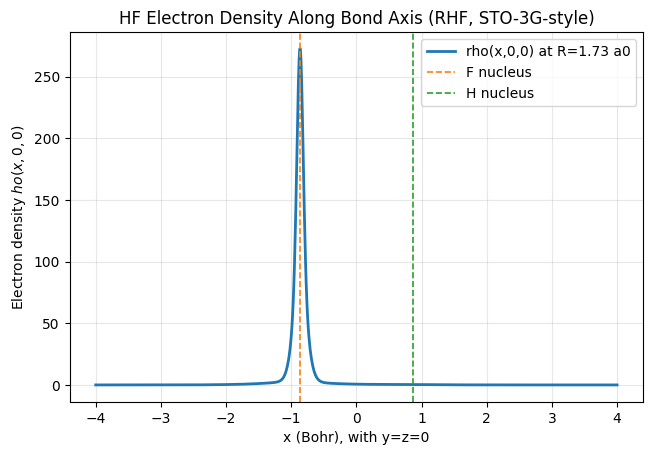

E_total at R = 1.73 Bohr: -98.88428452 Hartree
Line-density integral (F side, x<0): 46.311530
Line-density integral (H side, x>0): 0.517255
Density is skewed toward F (more electron density on fluorine side).


In [53]:
# COMMENT GUIDE:
# This cell computes total electron density for HF at equilibrium geometry.
# It evaluates general Cartesian Gaussian basis functions (supports s and p),
# constructs rho(x,0,0) from the converged P matrix, plots the bond-axis density,
# and reports left/right integrated line-density as a polarity diagnostic.

# Exercise 2(b): HF electron density along bond axis at equilibrium
import numpy as np
import matplotlib.pyplot as plt


# Unnormalized Cartesian Gaussian (s/p capable) at r.
def primitive_cartesian_gaussian_unnorm(r_vec, alpha, center, ijk):
    """Unnormalized Cartesian Gaussian: (x-Ax)^i (y-Ay)^j (z-Az)^k exp(-a|r-A|^2)."""
    i, j, k = ijk
    dx, dy, dz = r_vec - center
    return (dx ** i) * (dy ** j) * (dz ** k) * np.exp(-alpha * (dx * dx + dy * dy + dz * dz))


# General density evaluator supporting s and p basis terms.
def electron_density_at_point_general(r_vec, P, basis):
    # rho(r) = sum_ij P_ij * phi_i(r) * phi_j(r) * n_i * n_j
    nbf = len(basis)
    vals = np.zeros(nbf)
    for idx, b in enumerate(basis):
        vals[idx] = b['norm'] * primitive_cartesian_gaussian_unnorm(
            r_vec, b['exponent'], b['center'], b['ijk']
        )

    rho = 0.0
    for i in range(nbf):
        for j in range(nbf):
            rho += P[i, j] * vals[i] * vals[j]
    return rho


# Samples rho(x,0,0) for heteronuclear HF analysis.
def density_profile_x_axis(P, basis, x_grid):
    rho = np.zeros_like(x_grid)
    for ix, x in enumerate(x_grid):
        rho[ix] = electron_density_at_point_general(np.array([x, 0.0, 0.0]), P, basis)
    return rho


# Use equilibrium from part (a) experimental equilibrium bond length
R_eq_hf = 1.73
# Prepare HF basis and nuclear model at chosen bond length.
basis_hf, nuclei_hf, n_elec_hf = build_hf_basis_sto3g(R_eq_hf)
# Solve RHF and keep converged density matrix for rho(r).
E_hf_eq, P_hf_eq = run_hartree_fock_with_density(basis_hf, nuclei_hf, n_elec=n_elec_hf)

# x-axis profile through both nuclei
x = np.linspace(-4.0, 4.0, 801)
rho_x = density_profile_x_axis(P_hf_eq, basis_hf, x)

x_F = -R_eq_hf / 2.0
x_H = +R_eq_hf / 2.0

# Plot the computed profile/curve for quick physical interpretation.
plt.figure(figsize=(7.4, 4.8))
plt.plot(x, rho_x, lw=2.0, label=f'rho(x,0,0) at R={R_eq_hf:.2f} a0')
plt.axvline(x_F, color='tab:orange', ls='--', lw=1.2, label='F nucleus')
plt.axvline(x_H, color='tab:green', ls='--', lw=1.2, label='H nucleus')
plt.xlabel('x (Bohr), with y=z=0')
plt.ylabel(r'Electron density $ho(x,0,0)$')
plt.title('HF Electron Density Along Bond Axis (RHF, STO-3G-style)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Simple asymmetry metric: integrated line density left (F side) vs right (H side)
mask_left = x < 0.0
mask_right = x > 0.0
left_int = np.trapezoid(rho_x[mask_left], x[mask_left])
right_int = np.trapezoid(rho_x[mask_right], x[mask_right])

# Print compact numerical summary for report-ready values.
print(f'E_total at R = {R_eq_hf:.2f} Bohr: {E_hf_eq:+.8f} Hartree')
# Print compact numerical summary for report-ready values.
print(f'Line-density integral (F side, x<0): {left_int:.6f}')
# Print compact numerical summary for report-ready values.
print(f'Line-density integral (H side, x>0): {right_int:.6f}')
if left_int > right_int:
    # Print compact numerical summary for report-ready values.
    print('Density is skewed toward F (more electron density on fluorine side).')
else:
    # Print compact numerical summary for report-ready values.
    print('Density is skewed toward H (unexpected for HF).')


The bond density is clearly **asymmetric**, with electron density shifted toward the **F atom** rather than centered equally between H and F.

This indicates a **polar covalent bond** (unequal sharing), which matches chemical intuition: fluorine is much more electronegative than hydrogen, so it pulls electron density toward itself (consistent with partial charges $\delta^+$ on H and $\delta^-$ on F).


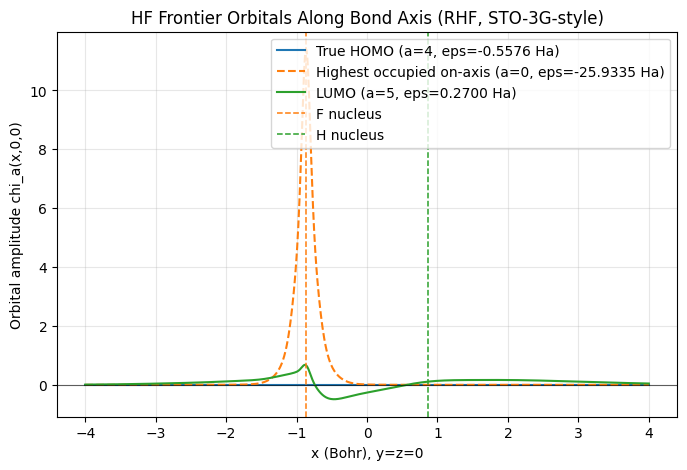

Total RHF energy at R=1.73 Bohr: -98.88428452 Hartree
True HOMO index = 4, eps = -0.557634 Ha
LUMO index      = 5, eps = +0.270028 Ha
Note: HOMO is nearly zero on the bond axis (pi-type symmetry node), which is expected.
On-axis occupied frontier index = 0, eps = -25.933525 Ha


In [54]:
# COMMENT GUIDE:
# This cell returns converged orbital coefficients C and MO energies epsilon from RHF,
# then evaluates orbital amplitudes chi_a(r) for selected orbital indices.
# It plots true HOMO/LUMO along the bond axis and also reports the highest occupied orbital
# with nonzero on-axis amplitude (useful when HOMO is pi-type and nodal on y=z=0).

# Exercise 2(c): Compute HOMO/LUMO orbitals chi(r) from converged C
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as slin


# Runs RHF SCF and returns E, P, orbital energies, and C matrix.
def run_hartree_fock_with_orbitals(basis, nuclei, n_elec=2, max_iter=50, tol=1e-6):
    num_basis = len(basis)
    N_nuc = len(nuclei)
    N_occ = n_elec // 2

    S = np.zeros((num_basis, num_basis))
    T = np.zeros((num_basis, num_basis))
    Vext = np.zeros((num_basis, num_basis))
    ERI = np.zeros((num_basis, num_basis, num_basis, num_basis))

    for i in range(num_basis):
        for j in range(num_basis):
            b1 = basis[i]
            b2 = basis[j]
            pref12 = b1['norm'] * b2['norm']

            S[i, j] = pref12 * overlap(b1['exponent'], b1['ijk'], b1['center'], b2['exponent'], b2['ijk'], b2['center'])
            T[i, j] = pref12 * kinetic(b1['exponent'], b1['ijk'], b1['center'], b2['exponent'], b2['ijk'], b2['center'])

            for n in range(N_nuc):
                nuc = nuclei[n]
                Vext[i, j] += pref12 * nuclear_attraction(
                    b1['exponent'], b1['ijk'], b1['center'],
                    b2['exponent'], b2['ijk'], b2['center'],
                    nuc['center']
                ) * (-nuc['Z'])

            for lam in range(num_basis):
                for sig in range(num_basis):
                    b3 = basis[lam]
                    b4 = basis[sig]
                    pref34 = b3['norm'] * b4['norm']
                    ERI[i, j, lam, sig] = pref12 * pref34 * electron_repulsion(
                        b1['exponent'], b1['ijk'], b1['center'],
                        b2['exponent'], b2['ijk'], b2['center'],
                        b3['exponent'], b3['ijk'], b3['center'],
                        b4['exponent'], b4['ijk'], b4['center']
                    )

    H_core = T + Vext
    eps, C = slin.eigh(H_core, S)

    P = np.zeros((num_basis, num_basis))
    for lam in range(num_basis):
        for sig in range(num_basis):
            for occ in range(N_occ):
                P[lam, sig] += 2.0 * C[lam, occ] * C[sig, occ]

    E_old = 0.0
    E_elec = 0.0
    for _ in range(max_iter):
        F = np.zeros((num_basis, num_basis))
        for i in range(num_basis):
            for j in range(num_basis):
                F[i, j] = H_core[i, j]
                for lam in range(num_basis):
                    for sig in range(num_basis):
                        J = ERI[i, j, lam, sig]
                        K = 0.5 * ERI[i, lam, sig, j]
                        F[i, j] += P[lam, sig] * (J - K)

        E_elec = 0.0
        for i in range(num_basis):
            for j in range(num_basis):
                E_elec += 0.5 * P[i, j] * (H_core[i, j] + F[i, j])

        if abs(E_elec - E_old) < tol:
            break
        E_old = E_elec

        eps, C = slin.eigh(F, S)
        P = np.zeros((num_basis, num_basis))
        for lam in range(num_basis):
            for sig in range(num_basis):
                for occ in range(N_occ):
                    P[lam, sig] += 2.0 * C[lam, occ] * C[sig, occ]

    V_nn = 0.0
    for a in range(N_nuc):
        for b in range(N_nuc):
            if a != b:
                dist = np.linalg.norm(nuclei[a]['center'] - nuclei[b]['center'])
                V_nn += 0.5 * nuclei[a]['Z'] * nuclei[b]['Z'] / dist

    E_total = E_elec + V_nn
    return E_total, P, eps, C


# Unnormalized Cartesian Gaussian (s/p capable) at r.
def primitive_cartesian_gaussian_unnorm(r_vec, alpha, center, ijk):
    i, j, k = ijk
    dx, dy, dz = r_vec - center
    return (dx ** i) * (dy ** j) * (dz ** k) * np.exp(-alpha * (dx * dx + dy * dy + dz * dz))


# Evaluates one MO amplitude chi_a(r) from C coefficients and basis.
def chi_orbital_at_point(r_vec, C, basis, orb_index):
    val = 0.0
    for i, b in enumerate(basis):
        phi_i = primitive_cartesian_gaussian_unnorm(r_vec, b['exponent'], b['center'], b['ijk'])
        val += C[i, orb_index] * phi_i * b['norm']
    return val


# Samples a selected orbital amplitude along the x-axis.
def orbital_profile_x(C, basis, orb_index, x_grid):
    vals = np.zeros_like(x_grid)
    for ix, x in enumerate(x_grid):
        vals[ix] = chi_orbital_at_point(np.array([x, 0.0, 0.0]), C, basis, orb_index)
    return vals


R_eq_hf = 1.73
# Prepare HF basis and nuclear model at chosen bond length.
basis_hf, nuclei_hf, n_elec_hf = build_hf_basis_sto3g(R_eq_hf)
# Solve RHF and keep orbital energies/coefficients for MO plots.
E_hf, P_hf, eps_hf, C_hf = run_hartree_fock_with_orbitals(basis_hf, nuclei_hf, n_elec=n_elec_hf)

n_occ = n_elec_hf // 2
homo_idx = n_occ - 1
lumo_idx = n_occ

x = np.linspace(-4.0, 4.0, 1001)
chi_homo = orbital_profile_x(C_hf, basis_hf, homo_idx, x)
chi_lumo = orbital_profile_x(C_hf, basis_hf, lumo_idx, x)

# For diatomics, true HOMO can be pi-type and exactly zero on the bond axis.
# To give a meaningful on-axis picture, also identify the highest occupied orbital
# with largest on-axis amplitude (sigma-like occupied frontier on axis).
occupied_indices = list(range(n_occ))
on_axis_strength = [np.max(np.abs(orbital_profile_x(C_hf, basis_hf, idx, x))) for idx in occupied_indices]
homo_on_axis_idx = occupied_indices[int(np.argmax(on_axis_strength))]
chi_homo_on_axis = orbital_profile_x(C_hf, basis_hf, homo_on_axis_idx, x)

x_F = -R_eq_hf / 2.0
x_H = +R_eq_hf / 2.0

# Plot the computed profile/curve for quick physical interpretation.
plt.figure(figsize=(8.0, 5.0))
plt.plot(x, chi_homo, label=f'True HOMO (a={homo_idx}, eps={eps_hf[homo_idx]:.4f} Ha)')
plt.plot(x, chi_homo_on_axis, '--', label=f'Highest occupied on-axis (a={homo_on_axis_idx}, eps={eps_hf[homo_on_axis_idx]:.4f} Ha)')
plt.plot(x, chi_lumo, label=f'LUMO (a={lumo_idx}, eps={eps_hf[lumo_idx]:.4f} Ha)')
plt.axhline(0.0, color='k', lw=0.8, alpha=0.6)
plt.axvline(x_F, color='tab:orange', ls='--', lw=1.1, label='F nucleus')
plt.axvline(x_H, color='tab:green', ls='--', lw=1.1, label='H nucleus')
plt.xlabel('x (Bohr), y=z=0')
plt.ylabel('Orbital amplitude chi_a(x,0,0)')
plt.title('HF Frontier Orbitals Along Bond Axis (RHF, STO-3G-style)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Print compact numerical summary for report-ready values.
print(f'Total RHF energy at R={R_eq_hf:.2f} Bohr: {E_hf:+.8f} Hartree')
# Print compact numerical summary for report-ready values.
print(f'True HOMO index = {homo_idx}, eps = {eps_hf[homo_idx]:+.6f} Ha')
# Print compact numerical summary for report-ready values.
print(f'LUMO index      = {lumo_idx}, eps = {eps_hf[lumo_idx]:+.6f} Ha')
if np.max(np.abs(chi_homo)) < 1e-6:
    # Print compact numerical summary for report-ready values.
    print('Note: HOMO is nearly zero on the bond axis (pi-type symmetry node), which is expected.')
# Print compact numerical summary for report-ready values.
print(f'On-axis occupied frontier index = {homo_on_axis_idx}, eps = {eps_hf[homo_on_axis_idx]:+.6f} Ha')


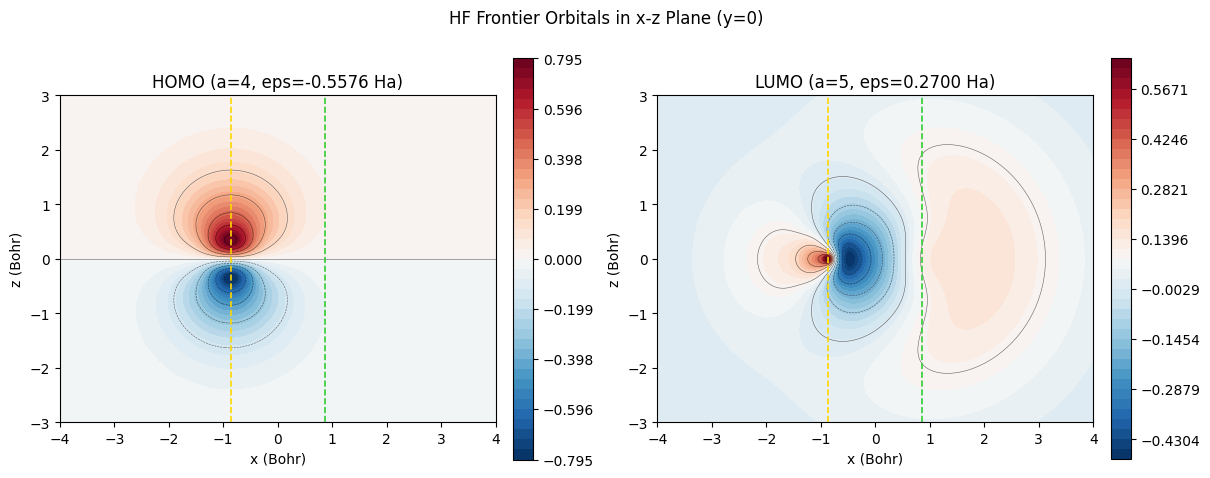

Computed at R = 1.73 Bohr
HOMO index = 4, energy = -0.557634 Ha
LUMO index = 5, energy = +0.270028 Ha


In [55]:
# COMMENT GUIDE:
# This cell generates 2D contour maps of HOMO and LUMO in the x-z plane (y=0).
# It evaluates chi_a(x,0,z) on a meshgrid, plots filled contours plus contour lines,
# marks nuclear positions, and reports orbital indices and energies used in the plots.

# Exercise 2(d): 2D contour plots of HOMO/LUMO in the x-z plane (y=0)
import numpy as np
import matplotlib.pyplot as plt

# Geometry and converged orbitals
R_eq_hf = 1.73
# Prepare HF basis and nuclear model at chosen bond length.
basis_hf, nuclei_hf, n_elec_hf = build_hf_basis_sto3g(R_eq_hf)
# Solve RHF and keep orbital energies/coefficients for MO plots.
E_hf, P_hf, eps_hf, C_hf = run_hartree_fock_with_orbitals(basis_hf, nuclei_hf, n_elec=n_elec_hf)

n_occ = n_elec_hf // 2
homo_idx = n_occ - 1
lumo_idx = n_occ

# Grid in x-z plane (y=0)
x = np.linspace(-4.0, 4.0, 220)
z = np.linspace(-3.0, 3.0, 180)
X, Z = np.meshgrid(x, z)

CHI_HOMO = np.zeros_like(X)
CHI_LUMO = np.zeros_like(X)

for iz in range(Z.shape[0]):
    for ix in range(X.shape[1]):
        r_vec = np.array([X[iz, ix], 0.0, Z[iz, ix]])
        CHI_HOMO[iz, ix] = chi_orbital_at_point(r_vec, C_hf, basis_hf, homo_idx)
        CHI_LUMO[iz, ix] = chi_orbital_at_point(r_vec, C_hf, basis_hf, lumo_idx)

# Plot settings
x_F = -R_eq_hf / 2.0
x_H = +R_eq_hf / 2.0
levels_homo = np.linspace(np.min(CHI_HOMO), np.max(CHI_HOMO), 41)
levels_lumo = np.linspace(np.min(CHI_LUMO), np.max(CHI_LUMO), 41)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)

cf1 = axes[0].contourf(X, Z, CHI_HOMO, levels=levels_homo, cmap='RdBu_r')
axes[0].contour(X, Z, CHI_HOMO, levels=12, colors='k', linewidths=0.4, alpha=0.6)
axes[0].axvline(x_F, color='gold', ls='--', lw=1.2)
axes[0].axvline(x_H, color='limegreen', ls='--', lw=1.2)
axes[0].set_title(f'HOMO (a={homo_idx}, eps={eps_hf[homo_idx]:.4f} Ha)')
axes[0].set_xlabel('x (Bohr)')
axes[0].set_ylabel('z (Bohr)')
axes[0].set_aspect('equal', adjustable='box')
fig.colorbar(cf1, ax=axes[0], fraction=0.046, pad=0.03)

cf2 = axes[1].contourf(X, Z, CHI_LUMO, levels=levels_lumo, cmap='RdBu_r')
axes[1].contour(X, Z, CHI_LUMO, levels=12, colors='k', linewidths=0.4, alpha=0.6)
axes[1].axvline(x_F, color='gold', ls='--', lw=1.2)
axes[1].axvline(x_H, color='limegreen', ls='--', lw=1.2)
axes[1].set_title(f'LUMO (a={lumo_idx}, eps={eps_hf[lumo_idx]:.4f} Ha)')
axes[1].set_xlabel('x (Bohr)')
axes[1].set_ylabel('z (Bohr)')
axes[1].set_aspect('equal', adjustable='box')
fig.colorbar(cf2, ax=axes[1], fraction=0.046, pad=0.03)

plt.suptitle('HF Frontier Orbitals in x-z Plane (y=0)', y=1.02)
plt.show()

# Print compact numerical summary for report-ready values.
print(f'Computed at R = {R_eq_hf:.2f} Bohr')
# Print compact numerical summary for report-ready values.
print(f'HOMO index = {homo_idx}, energy = {eps_hf[homo_idx]:+.6f} Ha')
# Print compact numerical summary for report-ready values.
print(f'LUMO index = {lumo_idx}, energy = {eps_hf[lumo_idx]:+.6f} Ha')
